# Point Cloud Alignment with Global Registration and ICP (Open3D)

In this notebook, I demonstrate how to align two partial point clouds using:
1. **Fast Global Registration (FGR)** for coarse alignment
2. **Point-to-Plane Iterative Closest Point (ICP)** for fine alignment

Open3D's built-in dataset `DemoICPPointClouds` was used, which contains two scans of the same scene from different viewpoints.

---


In [16]:
import open3d as o3d
import copy
from IPython.display import Image

## Step 1: Load and Visualize Dataset

To start the two partial scans has to be loaded. These will be referred to as the **source** and **target** point clouds.

The `source` will be aligned to the `target`.


In [17]:
# 1. Load dataset
dataset = o3d.data.DemoICPPointClouds()
source = o3d.io.read_point_cloud(dataset.paths[0])
target = o3d.io.read_point_cloud(dataset.paths[1])

## Step 2: Preprocess (Downsampling + Normals)

Before computing features,  the point clouds has to be downsampled to speed up computation and make it robust to noise.  
an estimation of the surface normals has to be done which will be required for Point-to-Plane ICP.


In [18]:
# Downsample for faster processing
voxel_size = 0.02
source_down = source.voxel_down_sample(voxel_size)
target_down = target.voxel_down_sample(voxel_size)

# Estimate normals
source_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
target_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))

## Step 3: Compute FPFH Features

Fast Point Feature Histograms (FPFH) describe local geometric properties.  
These are used in the global registration stage to find initial correspondences between the source and target clouds.


In [19]:
# 2. Compute FPFH features
source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_down, o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=100))
target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_down, o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=100))

## Step 4: Global Registration (Fast Global Registration)

**Fast Global Registration (FGR)** was used to obtain a coarse alignment.  
This helps avoid local minima in ICP by starting from a better initial transformation.


In [20]:
# 3. Fast Global Registration (initial alignment)
distance_threshold = voxel_size * 1.5
result_global = o3d.pipelines.registration.registration_fgr_based_on_feature_matching(
    source_down, target_down, source_fpfh, target_fpfh,
    o3d.pipelines.registration.FastGlobalRegistrationOption(
        maximum_correspondence_distance=distance_threshold
    )
)

print("Global alignment transformation:")
print(result_global.transformation)


Global alignment transformation:
[[ 0.84740809  0.00599421 -0.53090828  0.61788114]
 [-0.13928287  0.96742603 -0.21139335  0.77115622]
 [ 0.51234736  0.25308287  0.82063953 -1.45182646]
 [-0.          0.         -0.          1.        ]]


## Step 5: ICP Refinement (Point-to-Plane)

The coarse alignment was refined using **Point-to-Plane ICP**, which uses both point positions and surface normals for improved accuracy.


In [21]:
# 4. Refine with Point-to-Plane ICP
threshold = 0.02
result_icp = o3d.pipelines.registration.registration_icp(
    source, target, threshold, result_global.transformation,
    o3d.pipelines.registration.TransformationEstimationPointToPlane(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
)
print("Refined ICP transformation:")
print(result_icp.transformation)

Refined ICP transformation:
[[ 0.84047181  0.0066309  -0.5418147   0.64487137]
 [-0.14734416  0.96504311 -0.21675216  0.80951116]
 [ 0.52143728  0.26200731  0.81206855 -1.48472408]
 [ 0.          0.          0.          1.        ]]


## Step 6: Visualizing the Alignment

Now, a visualization of the alignment **before** and **after** ICP refinement is done. 


In [22]:
# Show 3D visualization BEFORE alignment
print("BEFORE alignment (Red = Source, Green = Target)")
o3d.visualization.draw_geometries([
    copy.deepcopy(source).paint_uniform_color([1, 0, 0]),
    copy.deepcopy(target).paint_uniform_color([0, 1, 0])
])


BEFORE alignment (Red = Source, Green = Target)


Here is a screenshot of the point clouds before ICP alignment – the red cloud represents the source, and the green cloud represents the target. The goal of the ICP algorithm is to align these two datasets as closely as possible by finding the optimal transformation.

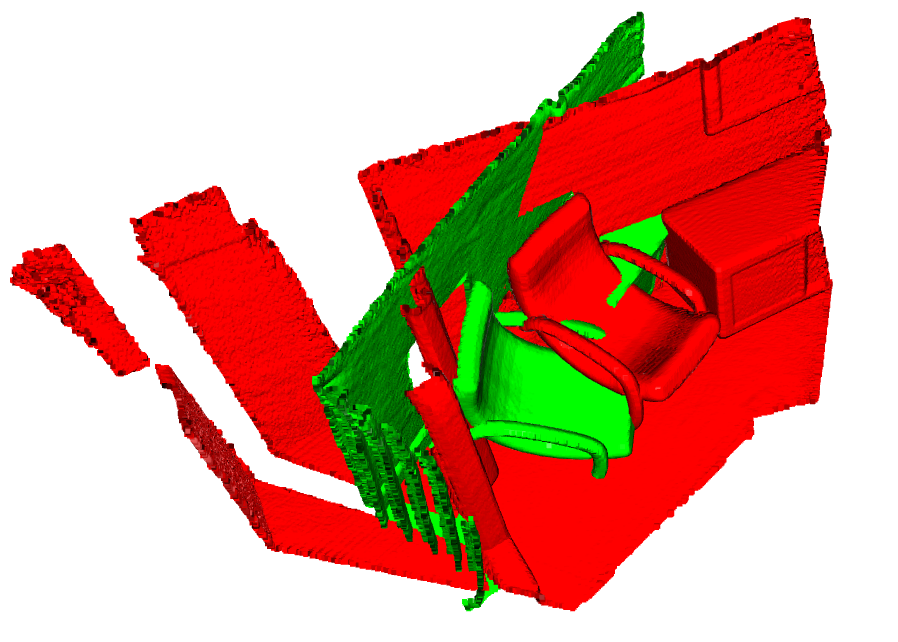

In [25]:
Image(filename="beforeicp.png")

In [26]:
# Show 3D visualization AFTER alignment
print("AFTER alignment (Red = Transformed Source, Green = Target)")
source_after_icp = copy.deepcopy(source)
source_after_icp.transform(result_icp.transformation)
o3d.visualization.draw_geometries([
    source_after_icp.paint_uniform_color([1, 0, 0]),
    copy.deepcopy(target).paint_uniform_color([0, 1, 0])
])

AFTER alignment (Red = Transformed Source, Green = Target)


And a screenshot of the point clouds after ICP alignment

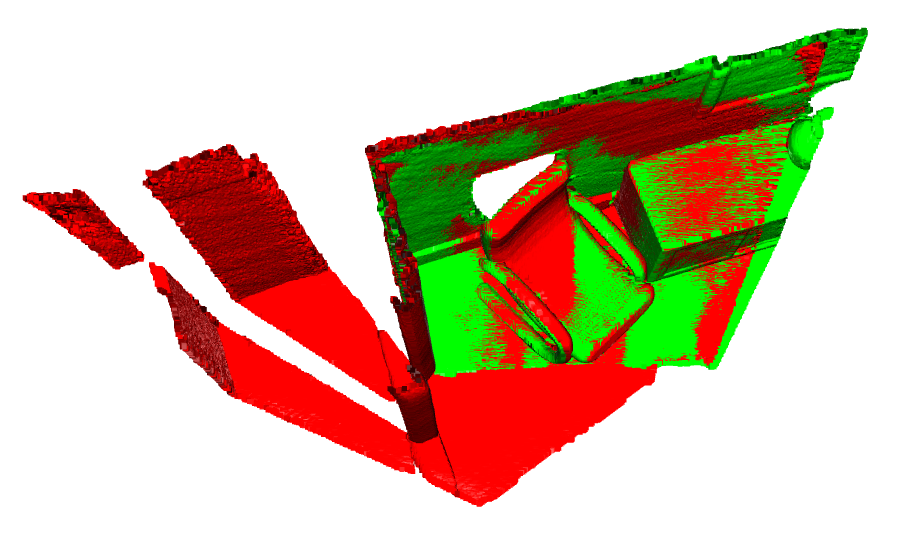

In [27]:
Image(filename="aftericp.png")

## Step 7: Learning output

- ICP needs a good initial guess; global registration solves this problem.
- Point-to-Plane ICP is generally more accurate than Point-to-Point for structured surfaces.
- Preprocessing (downsampling and normal estimation) improves speed and robustness.
- FPFH features are useful for matching different scans of the same scene.
- Open3D's built-in datasets make it easy to experiment without manually downloading large files.
